In [40]:
import os

import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as colors
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
import matplotlib as mpl

from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

from itertools import combinations
from adjustText import adjust_text
from shapely.validation import make_valid

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"] = ["Montserrat", "DejaVu Sans"]

# --- Configuration ---
path_to_scenarios = '/home/abhis/india_power/scenarios'
path_to_images = '/home/gterren/india_power/images/'

path_to_csvs = '/home/abhis/india_power/gridpath_india_viz/processed_data/'
path_to_data = '/home/abhis/india_power/gridpath_india_viz/data/'
path_to_input = '/home/gterren/india_power/input_data/'

In [2]:
def _opt_dist(x_, y_, d = 1.4, delta = 0.1):
    
    def __update_position(x, x_0, z):
        return x + ((x - x_0)/z)*delta, x_0 + ((x_0 - x)/z)*delta  
    
    while True:
        flag = True
        for i in range(x_.shape[0]):
            for j in range(x_.shape[0]):
                if i != j:
                    z = np.sqrt( (x_[j] - x_[i])**2 + (y_[j] - y_[i])**2 )
                    if z < d:
                        x_[j], x_[i] = __update_position(x_[j], x_[i], z)
                        y_[j], y_[i] = __update_position(y_[j], y_[i], z)
                        flag = False
        if flag:
            break

    return x_, y_

def _time_features(df_, column = "datetime"):
    df_["time"]  = pd.to_datetime(df_[column])
    df_["month"] = df_["time"].dt.month
    df_["day"]   = df_["time"].dt.day
    df_["hour"]  = df_["time"].dt.hour
    return df_

In [3]:
LOLH_ = pd.read_csv(path_to_csvs + 'lz_lolh_filtered-ra-8_prm_90_ccap.csv')
LOLH_ = _time_features(LOLH_, column = "timestamp")

USE_ = LOLH_[['month', 
              'day', 
              'hour', 
              'iteration', 
              'load_zone',
              'unserved_energy',
              'static_load']].copy()

USE_['normalized_unserved_energy'] =  100 * USE_['unserved_energy'] / USE_['static_load']

In [4]:
df_zone_ = USE_[['iteration', 
                  'month', 
                  'day' , 
                  'hour', 
                  'load_zone', 
                  'unserved_energy']].copy()

df_zone_stats_ = df_zone_.groupby(["load_zone"]).agg(total_unserved_energy=("unserved_energy", "sum"),
                                                     n_events=("unserved_energy", "size")).reset_index(drop = False)

df_temp_ = df_zone_[['iteration', 
                     'month', 
                     'day', 
                     'hour']].copy()

df_temp_ = df_temp_.drop_duplicates(keep="first").reset_index(drop = True)

groups_ = []
for i in range(df_temp_.shape[0]):
    iteration = df_temp_.loc[i, 'iteration']
    month     = df_temp_.loc[i, 'month']
    day       = df_temp_.loc[i, 'day']
    hour      = df_temp_.loc[i, 'hour']
    
    idx_ = df_zone_['iteration'] == iteration
    idx_ = idx_ & (df_zone_['month'] == month)          
    idx_ = idx_ & (df_zone_['day'] == day)          
    idx_ = idx_ & (df_zone_['hour'] == hour)       

    if idx_.sum() > 1:
        groups_.append(df_zone_.loc[idx_, 'load_zone'].to_list())

print(len(groups_))
rows_ = []

for i, group in enumerate(groups_):
    # optional: unique + sorted, to avoid duplicates and keep order consistent
    zones = sorted(set(group))
    
    # all unordered 2-combinations
    for z1, z2 in combinations(zones, 2):
        rows_.append({"event": i, "load_zone1": z1, "load_zone2": z2})

df_pairs_ = pd.DataFrame(rows_)
print(df_pairs_)

# Create canonical (sorted) pair columns
df_pairs_[["load_zoneA", 
           "load_zoneB"]] = df_pairs_[["load_zone1", 
                                       "load_zone2"]].apply(lambda row: pd.Series(sorted(row.values)), axis=1)

df_pairs_ = df_pairs_.groupby(["load_zoneA", 
                               "load_zoneB"]).size().reset_index(name="n_events")

print(df_pairs_)

47
     event          load_zone1   load_zone2
0        0  Dadra_Nagar_Haveli    Daman_Diu
1        0  Dadra_Nagar_Haveli      Gujarat
2        0           Daman_Diu      Gujarat
3        1               Delhi       Punjab
4        1               Delhi  Uttarakhand
..     ...                 ...          ...
262     46       Jammu_Kashmir   Puducherry
263     46       Jammu_Kashmir    Telangana
264     46         Maharashtra   Puducherry
265     46         Maharashtra    Telangana
266     46          Puducherry    Telangana

[267 rows x 3 columns]
            load_zoneA     load_zoneB  n_events
0       Andhra_Pradesh      Karnataka         1
1       Andhra_Pradesh         Kerala         1
2       Andhra_Pradesh     Puducherry         1
3       Andhra_Pradesh     Tamil_Nadu         1
4   Dadra_Nagar_Haveli      Daman_Diu        18
..                 ...            ...       ...
66          Puducherry      Telangana         4
67              Punjab  Uttar_Pradesh         4
68           

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


             load_zone  unserved_energy  n_events
0       Andhra_Pradesh     25172.726129         4
1           Chandigarh       124.509824         4
2   Dadra_Nagar_Haveli     75110.454612        59
3            Daman_Diu     11453.286316        18
4                Delhi     21529.682770         4
5                  Goa     12925.156753        17
6              Gujarat     89954.408641        23
7        Jammu_Kashmir      6959.342462         8
8            Karnataka     31752.857021         2
9               Kerala     31280.238859        10
10         Maharashtra     14513.142952         2
11          Puducherry      7351.551566         8
12              Punjab    155644.676679        27
13          Tamil_Nadu     34846.411777         4
14           Telangana     32794.036820         5
15       Uttar_Pradesh     72626.985330         6
16         Uttarakhand      5342.004011         9


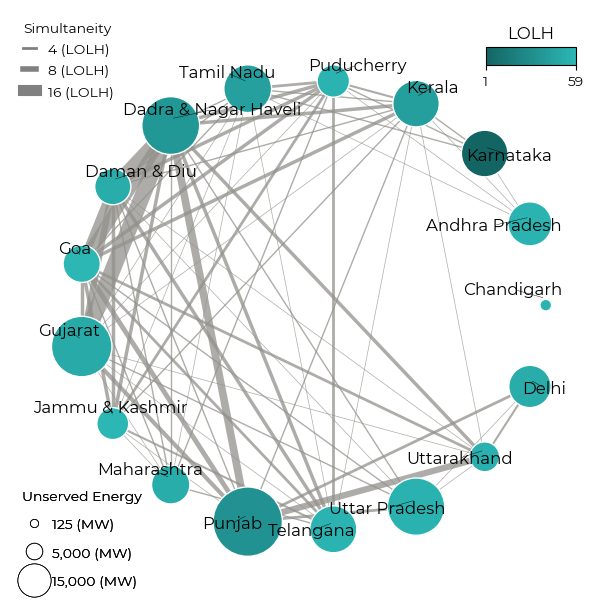

In [5]:
import networkx as nx

from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from matplotlib import cm, colors
from matplotlib.colors import LinearSegmentedColormap

def _simulateity_graph(ax, USE_, df_pairs_):

    df_ = df_pairs_.copy()

    load_zones_ = pd.unique(pd.concat([df_pairs_["load_zoneA"], df_pairs_["load_zoneB"]]))
    idx_ = USE_agg_["load_zone"].isin(load_zones_)

    USE_agg_["load_zone"] = USE_agg_["load_zone"].str.replace("Jammu_Kashmir", "Jammu & Kashmir", regex=False)
    USE_agg_["load_zone"] = USE_agg_["load_zone"].str.replace("Dadra_Nagar_Haveli", "Dadra & Nagar Haveli", regex=False)
    USE_agg_["load_zone"] = USE_agg_["load_zone"].str.replace("Daman_Diu", "Daman & Diu", regex=False)
    USE_agg_["load_zone"] = USE_agg_["load_zone"].str.replace("_", " ", regex=False)

    df_["load_zoneA"] = df_["load_zoneA"].str.replace("Jammu_Kashmir", "Jammu & Kashmir", regex=False)
    df_["load_zoneA"] = df_["load_zoneA"].str.replace("Dadra_Nagar_Haveli", "Dadra & Nagar Haveli", regex=False)
    df_["load_zoneA"] = df_["load_zoneA"].str.replace("Daman_Diu", "Daman & Diu", regex=False)
    df_["load_zoneA"] = df_["load_zoneA"].str.replace("_", " ", regex=False)

    df_["load_zoneB"] = df_["load_zoneB"].str.replace("Jammu_Kashmir", "Jammu & Kashmir", regex=False)
    df_["load_zoneB"] = df_["load_zoneB"].str.replace("Dadra_Nagar_Haveli", "Dadra & Nagar Haveli", regex=False)
    df_["load_zoneB"] = df_["load_zoneB"].str.replace("Daman_Diu", "Daman & Diu", regex=False)
    df_["load_zoneB"] = df_["load_zoneB"].str.replace("_", " ", regex=False)

    G = nx.Graph()
    units = .025

    # Add a single node with no connections
    G.add_nodes_from(list(USE_agg_.loc[~idx_, "load_zone"]))

    edges = list(df_[["load_zoneA", "load_zoneB", "n_events"]].itertuples(index=False, name=None))

    # Add edges with weight attribute
    for u, v, w in edges:
        G.add_edge(u, v, weight=w/2)

    #pos = nx.spring_layout(G, k=0.5)
    #pos = nx.shell_layout(G) 
    pos = nx.circular_layout(G)

    # Example: node size based on degree
    node_sizes = []
    for n in G.nodes():
        node_sizes.append(np.sqrt(USE_agg_.loc[USE_agg_["load_zone"] == n, "unserved_energy"].values[0]/units))

    # Extract edge weights for line width
    weights = [G[u][v]["weight"] for u, v in G.edges()]

    vals = USE_agg_["n_events"].to_numpy()

    norm = colors.Normalize(vmin = 1, vmax = max(vals))
    cmap = LinearSegmentedColormap.from_list("my_two", ['#2cb7b5','#136564'])

    node_colors = [cmap(norm(v)) for v in vals]

    nodes = nx.draw_networkx_nodes(G, pos,
                                node_color = node_colors,
                                node_size = node_sizes,
                                edgecolors = "w")

    nx.draw_networkx_edges(G, pos, 
                        width = weights, 
                        edge_color = '#92918b', 
                        alpha = .75)  # thicker = stronger ties

    # ---- Colorbar in top right ----
    cmap = LinearSegmentedColormap.from_list("my_two", ['#136564', '#2cb7b5'])

    nodes.set_cmap(cmap)
    cax = fig.add_axes([0.8, 0.9, 0.15, 0.03])   # (left, bottom, width, height)
    cb = plt.colorbar(nodes, cax=cax, orientation="horizontal")
    cb.ax.tick_params(labelsize=10)
    cb.set_label("LOLH",fontsize=12, labelpad=-45)
    vmax, vmin = nodes.get_clim()
    cb.set_ticks([vmax, vmin])
    cb.set_ticklabels([1, max(vals)])

    # 2. Draw labels (slightly offset so they start away from the dots)
    label_artists = {}
    for n, (x, y) in pos.items():
        # small vertical offset so labels aren't centered on the node
        label_artists[n] = ax.text(x, y + 0.03,
                                s=n,
                                fontsize=12,
                                ha="center",
                                va="center")

    # 3. Use adjust_text to avoid overlaps (and nudge them off nodes)
    texts = list(label_artists.values())

    adjust_text(texts,
                ax=ax,
                # expand around the scatter points (the nodes)
                expand_points=(1.2, 1.4),
                expand_text=(1.05, 1.2),
                arrowprops=dict(arrowstyle="-", color="k", lw=0.3),  # optional arrows
                only_move={"text": "xy"})

    legend_handles = [
        Line2D(
            [0], [0],
            color="gray",
            lw=4/2,
            label="4 (LOLH)"
        ),
        Line2D(
            [0], [0],
            color="gray",
            lw=8/2,
            label="8 (LOLH)"
        ),
        Line2D(
            [0], [0],
            color="gray",
            lw=16/2,
            label="16 (LOLH)"
        ),
    ]

    leg1 = ax.legend(handles=legend_handles,
                    loc="upper left",
                    frameon=False,
                    title="Simultaneity")

    ax.add_artist(leg1) 

    # print(USE_agg_["unserved_energy"].values[0])
    # print(np.sqrt(USE_agg_["unserved_energy"].values[0]/units))
    # Example sizes and labels (e.g. MW of capacity)
    sizes  = [6, 12, 24]
    labels = ["125 (MW)", "5,000 (MW)", "15,000 (MW)"]

    handles = []
    for s, lab in zip(sizes, labels):
        ms = s  # rough match to scatter sizing
        h = Line2D([], [], 
                marker="o",
                markersize=ms,
                linestyle="None",
                markerfacecolor="none",
                markeredgecolor='k',
                markeredgewidth=.5,
                label=lab)
        
        handles.append(h)

    leg2 = ax.legend(handles=handles,
                    title='Unserved Energy',
                    frameon=False,
                    loc="lower left",
                    labelspacing=1)

    ax.add_artist(leg2) 

    ax.margins(0.1)  # 0.1–0.3 usually works well

    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

USE_['n_events'] = 1
USE_agg_ = USE_.groupby(["load_zone"]).agg({"unserved_energy": "sum",
                                            'n_events': "sum"}).reset_index(drop=False)
print(USE_agg_)

fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

_simulateity_graph(ax, USE_agg_, df_pairs_)

plt.savefig(path_to_images + '/USE_simulateity.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [6]:
# --- Load shapefile ---
_bhutan     = gpd.read_file(path_to_data + r"map/bhutan/bt.shp").to_crs("epsg:4326")
_india      = gpd.read_file(path_to_data + r"map/india/india-polygon.shp").to_crs("epsg:4326")
load_zones_ = gpd.read_file(path_to_input + r"load_zones.csv")

_india['geometry'] = _india['geometry'].apply(lambda geom: make_valid(geom) if geom else None)
_india             = _india.dropna(subset=['geometry'])

_nothern      = _india.loc[[4, 10, 11, 22, 24, 25, 30, 31, 35, 36]].dissolve().buffer(.025)#.to_crs(epsg=3395).to_crs("epsg:4326")
_northeastern = _india.loc[[1, 2, 18, 19, 20, 21, 29]].dissolve()
_western      = _india.loc[[5, 6, 7, 8, 9, 16, 17]].dissolve()
_southern     = _india.loc[[13, 14, 23, 27, 28, 34]].dissolve()
_eastern      = _india.loc[[3, 12, 26, 32, 33]].dissolve()
_regions      = pd.concat([_northeastern, _western, _southern, _eastern], axis = 0)

# Harmonize naming
_india = _india.rename(columns={'st_nm': 'load_zone'})
_india['load_zone'] = _india['load_zone'].str.replace(" ", "_").str.replace("_and_", "_")

# Fix union and drop duplicates (as in your workflow)
_india.loc[35, 'geometry'] = _india.loc[35, 'geometry'].union(_india.loc[36, 'geometry'])
_india = _india.drop([0, 36]).reset_index(drop=True)

city_ = pd.read_csv(path_to_input + r"transmission/major_cities_india.csv")
city_ = city_.drop(columns = ['state', 'major_city'])
city_ = city_.rename(columns = {'acronym': 'load_zone_abr'})

/tmp/ipykernel_4011346/1398638517.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  _nothern      = _india.loc[[4, 10, 11, 22, 24, 25, 30, 31, 35, 36]].dissolve().buffer(.025)#.to_crs(epsg=3395).to_crs("epsg:4326")


In [7]:
load_zones_ = pd.read_csv(path_to_input + r"/load_zones.csv").drop(columns = ['state', 'rps_zone'])
load_zones_ = pd.merge(city_, load_zones_, on  = 'load_zone_abr', 
                                           how = 'inner')

load_zones_ = load_zones_.sort_values(by = 'load_zone').reset_index(drop = True)

load_zones_p_ = load_zones_.copy()

load_zones_p_['longitude'], load_zones_p_['latitude'] = _opt_dist(load_zones_p_['longitude'].to_numpy(), load_zones_p_['latitude'].to_numpy())

load_zones_p_.loc[31, 'latitude'] = load_zones_.loc[31, 'latitude']
load_zones_p_.loc[7, 'latitude']  = load_zones_.loc[7, 'latitude']

load_zones_p_.loc[31, 'latitude']  += .05
load_zones_p_.loc[31, 'longitude'] += .15
load_zones_p_.loc[13, 'latitude']  -= .1
load_zones_p_.loc[15, 'longitude'] -= .175
load_zones_p_.loc[29, 'longitude'] -= .6
load_zones_p_.loc[29, 'latitude'] -= .15
#load_zones_p_.loc[30, 'longitude'] += .5
load_zones_p_.loc[34, 'latitude']  += .325
load_zones_p_.loc[34, 'longitude'] += .5
# load_zones_p_.loc[7, 'latitude']  += 1.1
# load_zones_p_.loc[7, 'longitude'] -= 1.55
load_zones_p_.loc[28, 'latitude']  += .4
#load_zones_p_.loc[28, 'longitude'] -= .125
#load_zones_p_.loc[26, 'latitude']  += .2
load_zones_p_.loc[26, 'longitude'] += .7
#load_zones_p_.loc[19, 'latitude']  += .1
load_zones_p_.loc[19, 'longitude'] -= .3
load_zones_p_.loc[8, 'longitude'] += .25
load_zones_p_.loc[13, 'latitude']  -= .15
load_zones_p_.loc[13, 'longitude'] += .15
load_zones_p_.loc[16, 'longitude'] += .125

load_zones_p_.loc[5, 'latitude']  -= .15
load_zones_p_.loc[5, 'longitude'] += .15

load_zones_p_['position'] = 1

# load_zones_p_.loc[15, 'position'] = 0
# load_zones_p_.loc[25, 'position'] = 0
# load_zones_p_.loc[5, 'position']  = 1
# load_zones_p_.loc[6, 'position']  = 0
# load_zones_p_.loc[14, 'position'] = 0
# load_zones_p_.loc[30, 'position'] = 0
# load_zones_p_.loc[2, 'position']  = 0
# load_zones_p_.loc[10, 'position'] = 0
# load_zones_p_.loc[26, 'position'] = 0
# load_zones_p_.loc[27, 'position'] = 0
# load_zones_p_.loc[3, 'position']  = 2
# load_zones_p_.loc[2, 'position']  = 2
# load_zones_p_.loc[11, 'position'] = 2
print(load_zones_p_)

   load_zone_abr       region_x   latitude  longitude           load_zone  \
0             AP       Southern  17.704167  83.297778      Andhra_Pradesh   
1             AR  North-Eastern  27.398913  93.594569   Arunachal_Pradesh   
2             AS  North-Eastern  26.560107  91.648131               Assam   
3             BH         Bhutan  27.253741  89.779137              Bhutan   
4             BR        Eastern  25.600000  85.100000               Bihar   
5             CH       Northern  30.255695  76.785312          Chandigarh   
6             CG        Central  21.250000  81.630000        Chhattisgarh   
7             DH        Western  20.270000  73.701346  Dadra_Nagar_Haveli   
8             DD        Western  20.694256  72.463559           Daman_Diu   
9             DL       Northern  28.953212  76.997684               Delhi   
10            GA        Western  15.398056  73.811111                 Goa   
11            GJ        Western  23.030000  72.580000             Gujarat   

In [8]:
print(USE_.groupby(['month', 'day', 'hour', 'iteration']).agg({'unserved_energy': 'sum',
                                                               'n_events': 'sum'}).reset_index(drop = False).sort_values(by = 'unserved_energy', ascending = False))

    month  day  hour  iteration  unserved_energy  n_events
7       3   25    15         14     44969.512606         8
0       2    7     7         17     43206.018979         5
1       2    7    17         17     37757.869151         4
39      9   12    18         17     36139.225283         7
12      7    4    19          8     27301.122651         3
..    ...  ...   ...        ...              ...       ...
32      8   31    15         17        80.818882         1
6       3   10    14         11        49.381956         1
31      8   16    11         17        30.334489         1
29      8    2    12         18         9.767572         1
30      8   11    15         17         3.588882         1

[91 rows x 6 columns]


In [9]:
path_to_csvs = '/home/abhis/india_power/gridpath_india_viz/csvs/'

tech_labels_ = pd.read_csv('/home/gterren/india_power/gridpath_india_viz/csvs/technology_labels.csv') 
scenarios_   = pd.read_csv(path_to_csvs + 'ra-no_prm_no_ccap.csv')

tech_labels_.loc[tech_labels_['group'] == 'Import', 'group_color'] = tech_labels_.loc[tech_labels_['group'] == 'Export', 'group_color'].to_numpy()[0]
tech_labels_.loc[tech_labels_['group'] == 'Shedding', 'group_color'] = "#c94f39"

In [10]:
# Load and processing system load timepoints
def _processing_transmission_timepoints(scenarios_, iteration, month, day, hour):

    df_flows_ = []
    df_loads_ = []
    df_projects_ = []

    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)
        for dirpath, dirnames, filenames in os.walk(path_to_scenario):

            if dirpath.split('/')[-1] == 'results':

                # Add iteration descriptors to dataframe
                I = dirpath.split('/')[-6].split('_')[-1]

                W = dirpath.split('/')[-5].split('_')[-1]
                H = dirpath.split('/')[-4].split('_')[-1]
                A = dirpath.split('/')[-3].split('_')[-1]

                if iteration == int(I):
                    print(dirpath)

                    df_load_ = pd.read_csv(os.path.join(dirpath, 'system_load_zone_timepoint.csv'), low_memory = False)

                    df_load_['timepoint'] = df_load_['timepoint'].astype(str)
                    df_load_['month']     = df_load_['timepoint'].str[4:6].astype(int)
                    df_load_['day']       = df_load_['timepoint'].str[6:8].astype(int)
                    df_load_['hour']      = df_load_['timepoint'].str[8:10].astype(int)
   
                    df_loads_.append(df_load_)

                    df_flow_ = pd.read_csv(os.path.join(dirpath, 'transmission_timepoint.csv'), low_memory = False)
                    df_flow_['transmission_line'] = df_flow_['transmission_line'].str.replace('_new','')
                    
                    df_flow_['timepoint'] = df_flow_['timepoint'].astype(str)
                    df_flow_['month']     = df_flow_['timepoint'].str[4:6].astype(int)
                    df_flow_['day']       = df_flow_['timepoint'].str[6:8].astype(int)
                    df_flow_['hour']      = df_flow_['timepoint'].str[8:10].astype(int)
   
                    df_flows_.append(df_flow_)

                    df_project_ = pd.read_csv(os.path.join(dirpath, 'project_timepoint.csv'), low_memory = False)
    
                    df_project_['timepoint'] = df_project_['timepoint'].astype(str)
                    df_project_['month']     = df_project_['timepoint'].str[4:6].astype(int)
                    df_project_['day']       = df_project_['timepoint'].str[6:8].astype(int)
                    df_project_['hour']      = df_project_['timepoint'].str[8:10].astype(int)

                    df_projects_.append(df_project_)

                    df_tx_ = pd.read_csv(os.path.join(dirpath, 'transmission_period.csv'), low_memory = False)
                    df_tx_['transmission_line'] = df_tx_['transmission_line'].str.replace('_new','')

    df_loads_ = pd.concat(df_loads_).reset_index(drop = True)

    idx_ = df_loads_['month'] == month
    idx_ = idx_ & (df_loads_['day'] == day)          
    idx_ = idx_ & (df_loads_['hour'] == hour)     

    df_loads_ = df_loads_.loc[idx_].reset_index(drop = True)

    df_loads_ = df_loads_.groupby(['load_zone']).agg({'static_load_mw': 'sum', 
                                                      'total_power_mw': 'sum',
                                                      'net_imports_mw': 'sum',
                                                      'overgeneration_mw': 'sum', 
                                                      'unserved_energy_mw': 'sum'}).reset_index(drop = False)

    df_projects_ = pd.concat(df_projects_).reset_index(drop = True)

    idx_ = df_projects_['month'] == month
    idx_ = idx_ & (df_projects_['day'] == day)          
    idx_ = idx_ & (df_projects_['hour'] == hour)     

    df_projects_ = df_projects_.loc[idx_].reset_index(drop = True)

    df_projects_ = df_projects_.groupby(['load_zone',
                                         'technology',
                                         'operational_type']).agg({'power_mw': 'sum', 
                                                                   'discharge_mw': 'sum',
                                                                   'charge_mw': 'sum'}).reset_index(drop = False)
    
    df_flows_ = pd.concat(df_flows_).reset_index(drop = True)

    idx_ = df_flows_['month'] == month
    idx_ = idx_ & (df_flows_['day'] == day)          
    idx_ = idx_ & (df_flows_['hour'] == hour)     

    df_flows_ = df_flows_.loc[idx_].reset_index(drop = True)

    df_flows_ = df_flows_.groupby(['transmission_line', 
                                   'load_zone_from', 
                                   'load_zone_to']).agg({'transmission_flow_mw': 'sum', 
                                                         'transmission_losses_lz_from': 'sum', 
                                                         'transmission_losses_lz_to': 'sum'}).reset_index(drop = False)
    
    df_tx_ = df_tx_.groupby(['transmission_line', 
                             'load_zone_from', 
                             'load_zone_to']).agg({'max_mw': 'sum'}).reset_index(drop = False)

    df_flows_ = pd.merge(df_flows_, df_tx_, on = ['transmission_line', 
                                                  'load_zone_from', 
                                                  'load_zone_to'], how = 'inner')

    return df_loads_, df_projects_, df_flows_

iteration = 14
month     = 3       
day       = 25
hour      = 15

df_loads_, df_projects_, df_flows_ = _processing_transmission_timepoints(scenarios_, iteration, month, day, hour)
print(df_loads_.shape, df_projects_.shape, df_flows_.shape)
print(df_loads_['unserved_energy_mw'].sum())

/home/abhis/india_power/scenarios/ra_scenarios/no_prm_no_ccap/pier_no_prm_no_ccap_2040_14/weather_iteration_14/hydro_iteration_14/availability_iteration_9/1/results
/home/abhis/india_power/scenarios/ra_scenarios/no_prm_no_ccap/pier_no_prm_no_ccap_2040_14/weather_iteration_14/hydro_iteration_14/availability_iteration_9/2/results
/home/abhis/india_power/scenarios/ra_scenarios/no_prm_no_ccap/pier_no_prm_no_ccap_2040_14/weather_iteration_14/hydro_iteration_14/availability_iteration_9/3/results
/home/abhis/india_power/scenarios/ra_scenarios/no_prm_no_ccap/pier_no_prm_no_ccap_2040_14/weather_iteration_14/hydro_iteration_14/availability_iteration_9/4/results
/home/abhis/india_power/scenarios/ra_scenarios/no_prm_no_ccap/pier_no_prm_no_ccap_2040_14/weather_iteration_14/hydro_iteration_14/availability_iteration_9/5/results
/home/abhis/india_power/scenarios/ra_scenarios/no_prm_no_ccap/pier_no_prm_no_ccap_2040_14/weather_iteration_14/hydro_iteration_14/availability_iteration_9/6/results
/home/abhi

50.0 34162.14225739856


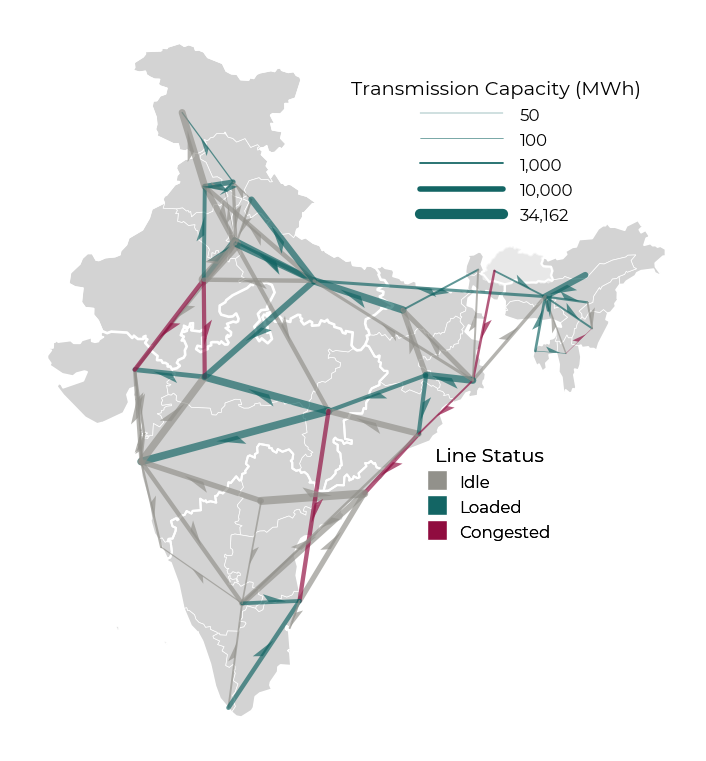

In [11]:
def _plot_transmission_status(ax, df_flows_, load_zones_,  
                              arrow = True, 
                              legend = True,
                              idle = False):

    def __f(x):
        return np.sqrt(np.absolute(x))/25
    
    df_ = df_flows_.copy()  

    df_['capacity_factor'] = 100. * df_['transmission_flow_mw'] / df_['max_mw']
    tx_min = df_['max_mw'].min()
    tx_max = df_['max_mw'].max()
    print(tx_min, tx_max)

    units = 1
    _norm = colors.Normalize(vmin = 0, vmax = 100)
    _cmap = LinearSegmentedColormap.from_list("my_two", ['#2cb7b5','#136564'])

    for i in range(df_.shape[0]):
        load_zone_to_   = load_zones_.loc[load_zones_['load_zone'] == df_.loc[i, 'load_zone_to']]
        load_zone_from_ = load_zones_.loc[load_zones_['load_zone'] == df_.loc[i, 'load_zone_from']]

        lon_from = load_zone_from_['longitude'].to_numpy()[0]
        lon_to   = load_zone_to_['longitude'].to_numpy()[0]
        
        B  = df_.loc[i, 'max_mw']
        cf = df_.loc[i, 'capacity_factor']
        w  = np.sign(cf)
        z  = __f(B/units)

        x_ = np.concatenate([load_zone_from_['latitude'].to_numpy(), load_zone_to_['latitude'].to_numpy()], axis = 0)
        y_ = np.concatenate([load_zone_from_['longitude'].to_numpy(), load_zone_to_['longitude'].to_numpy()], axis = 0)

        if np.abs(cf) == 0:
            if idle:
                color = '#92918b'
                show = True
            else:
                show = False
        elif np.abs(cf) == 100:
            color = '#900C3F'
            show = True
        else:
            show = True
            color = '#136564'


        if show:
            line = ax.plot(y_, x_, 
                        lw             = z,
                        zorder         = 10, 
                        color          = color,
                        solid_capstyle = 'round', 
                        alpha          = .675)


            if arrow:
                l = .3 + np.sqrt(z)/4.

                dy = (y_[1] - y_[0])/2.
                dx = (x_[1] - x_[0])/2.
                ds = np.sqrt(dy**2 + dx**2)
                lx = dx/ds
                ly = dy/ds
                
                if w > 0. :
                    ax.arrow(y_[0] + dy, x_[0] + dx, ly*l, lx*l, 
                            overhang   = 0.25, 
                            shape      = 'right', 
                            color      = color,
                            ls         = 'None', 
                            head_width = l, 
                            zorder     = 11, 
                            alpha      = .675,
                            length_includes_head = True)
                else:
                    ax.arrow(y_[0] + dy, x_[0] + dx, -ly*l, -lx*l, 
                            overhang   = 0.25, 
                            shape      = 'right', 
                            color      = color,
                            ls         = 'None', 
                            head_width = l, 
                            zorder     = 11, 
                            alpha      = .675,
                        length_includes_head = True)
            
    _india.plot(ax = ax, zorder = 1, color = 'lightgray', lw = 0.5, edgecolor = 'white')
    _bhutan.plot(ax = ax, zorder = 1, color = 'lightgray', lw = 1.5, alpha = .5, edgecolor = 'white')

    _nothern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _northeastern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _western.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _southern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _eastern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')

    if legend:
        line1 = Line2D([], [], color = '#136564', lw = __f(tx_min/units), solid_capstyle ='round')
        line2 = Line2D([], [], color = '#136564', lw = __f(100/units), solid_capstyle ='round')
        line3 = Line2D([], [], color = '#136564', lw = __f(1000/units), solid_capstyle ='round')
        line4 = Line2D([], [], color = '#136564', lw = __f(10000/units), solid_capstyle ='round')
        line5 = Line2D([], [], color = '#136564', lw = __f(tx_max/units), solid_capstyle ='round')
    
        leg1 = ax.legend((line1, line2, line3, line4, line5), 
                         (f'{int(tx_min):,}', f'{int(100):,}', f'{int(1000):,}', f'{int(10000):,}', f'{int(tx_max):,}'), 
                         title_fontsize = 14,
                         title          = 'Transmission Capacity (MWh)',
                         handlelength   = 5.,
                         handletextpad  = 1.,
                         labelspacing   = .5,
                         frameon        = False, 
                         bbox_to_anchor = (0.475, 0.925), 
                         prop           = {'size': 12})
        
        ax.add_artist(leg1) 

        risk_handle = []
        if idle:

            risk_handle.append(Line2D([0], [0],
                                marker="s",              # square marker
                                color="none",            # no line
                                markerfacecolor='#92918b',
                                markersize=15,
                                markeredgecolor = 'w',
                                linestyle="None",
                                label="Idle") )
        
        risk_handle.append(Line2D([0], [0],
                            marker="s",              # square marker
                            color="none",            # no line
                            markerfacecolor='#136564',
                            markersize=15,
                            markeredgecolor = 'w',
                            linestyle="None",
                            label="Loaded") )

        risk_handle.append(Line2D([0], [0],
                            marker="s",              # square marker
                            color="none",            # no line
                            markerfacecolor='#900C3F',
                            markersize=15,
                            markeredgecolor = 'w',
                            linestyle="None",
                            label="Congested") )
        
        leg2 = ax.legend(handles=risk_handle, 
                         loc=(0.6, 0.275), 
                         frameon = False, 
                         title = 'Line Status',
                         title_fontsize = 14,
                         fontsize = 12) 

        ax.add_artist(leg2) 

    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

    ax.set_xticks([], [])
    ax.set_yticks([], [])

fig, ax = plt.subplots(1, 1, figsize = (7.5, 7.5), constrained_layout = True)

_plot_transmission_status(ax, df_flows_, load_zones_, 
                          arrow = True, 
                          legend = True, 
                          idle = True)

plt.savefig(path_to_images + '/lines_congestion.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

/tmp/ipykernel_4011346/3429420559.py:91: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


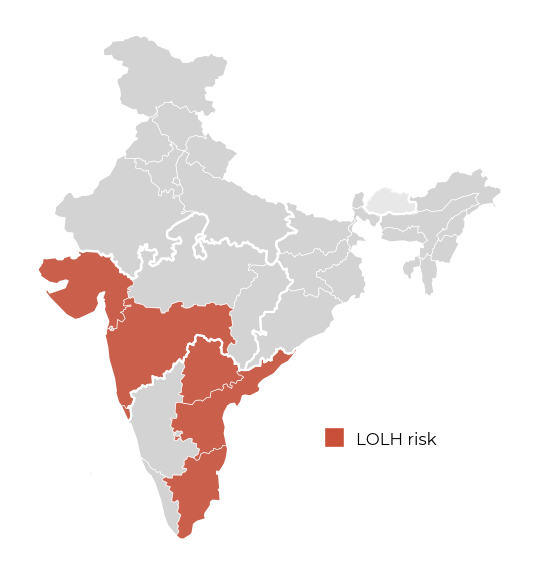

In [12]:
def _plot_risky_states(ax, df_load_, legend = True, name = False):
    
    df_ = df_load_.copy()

    _india.plot(ax = ax, zorder = 1, color = 'lightgray', lw = 0.5, edgecolor = 'white')
    _bhutan.plot(ax = ax, zorder = 1, color = 'lightgray', lw = 1.5, alpha = .5, edgecolor = 'white')

    df_ = df_.loc[df_['unserved_energy_mw'] > 0.].reset_index(drop = True)

    idx_ = _india["load_zone"].isin(df_['load_zone'].to_numpy())

    df_ = pd.merge(df_, _india, on = ['load_zone'], how = 'inner')
    df_ = gpd.GeoDataFrame(df_, geometry="geometry")
    # LOL states red with black border
    df_.plot(ax=ax, 
             color="#c94f39", 
             edgecolor="white", 
             alpha = 0.875,
             lw = 0.5, 
             zorder=2)
    
    _nothern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _northeastern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _western.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _southern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _eastern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')

    if name:
        # Labels for violating states
        df_["label_point"] = df_['geometry'].representative_point()

    
        texts_ = []
        for _, row in df_.iterrows():
            #state_name = row["load_zone_full"]
            #state_name = row["load_zone_abr"]
            state_name = row["load_zone"]

            state_name = state_name.replace("_", " ")
            state_name = state_name.replace("Jammu Kashmir", "Jammu, Kashmir & Ladakh")
            state_name = state_name.replace("Daman Diu", "Daman & Diu")
            state_name = state_name.replace("Dadra Nagar Haveli", "Dadra Nagar & Haveli")

            text = ax.text(row["label_point"].x,
                        row["label_point"].y,
                        state_name,
                        fontsize = 11,
                        ha="center",
                        va="center",
                        zorder = 15)
            
            texts_.append(text)

        # Let adjustText move the labels to avoid overlap
        adjust_text(texts_,
                    ax = ax, 
                    zorder = 14,
                    expand_text=(1, 1),
                    arrowprops=dict(arrowstyle="-", 
                                    color="k", 
                                    linewidth=0.25))
    
    if legend:
        risk_handle = Line2D([0], [0],
                             marker="s",              # square marker
                             color="none",            # no line
                             markerfacecolor="#c94f39",
                             markersize=15,
                             markeredgecolor = 'w',
                             linestyle="None",
                             label="LOLH risk")

        ax.legend(handles=[risk_handle], 
                  loc=(0.6, 0.2), 
                  frameon = False, 
                  fontsize = 12) 

    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

    ax.set_xticks([], [])
    ax.set_yticks([], [])

fig, ax = plt.subplots(1, 1, figsize = (7.5, 7.5), constrained_layout = True)

_plot_risky_states(ax, df_loads_, legend = True, name = False)

plt.savefig(path_to_images + '/lolh_risk_map.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.tight_layout()
plt.show()

50.0 34162.14225739856


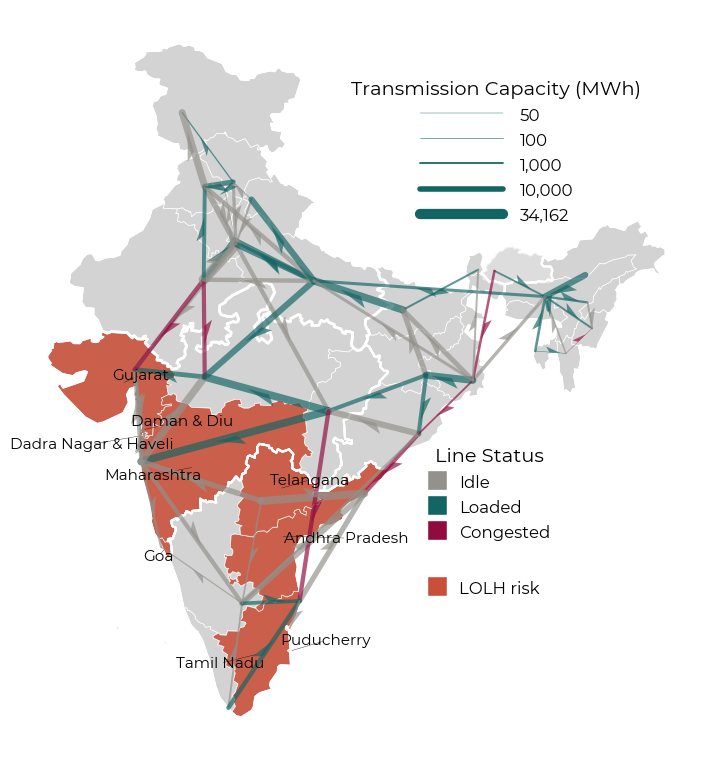

In [13]:
fig, ax = plt.subplots(1, 1, figsize = (7.5, 7.5), constrained_layout = True)

_plot_transmission_status(ax, df_flows_, load_zones_, 
                          arrow  = True, 
                          legend = True, 
                          idle   = True)

_plot_risky_states(ax, df_loads_, 
                   name   = True,
                   legend = True)

plt.savefig(path_to_images + '/lolh_map_and_lines_congention.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [49]:
# Group projects by technology
def _rename_technology(df_, tech_labels_):

    for group in tech_labels_['group'].unique():
        df_.loc[df_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 
                'technology'] = group
        
    return df_

idx_ = df_projects_['operational_type'] == 'stor'

df_stor_ = df_projects_.loc[idx_].reset_index(drop = True)
df_gen_  = df_projects_.copy()

df_stor_ = df_stor_.groupby(['load_zone']).agg({'charge_mw': 'sum'}).reset_index(drop = False)

df_gen_ = _rename_technology(df_gen_, tech_labels_)

df_gen_ = df_gen_.groupby(['load_zone',
                           'technology']).agg({'power_mw': 'sum'}).reset_index(drop = False)


df_ = df_loads_[['load_zone', 
                 'static_load_mw', 
                 'net_imports_mw', 
                 'unserved_energy_mw']].copy()

df_ = df_.merge(df_stor_, on = ['load_zone'], how = 'left').fillna(0.)

idx_ = df_['net_imports_mw'] > 0.

df_['Import'] = 0.
df_['Export'] = 0.

df_['Load']   = df_['static_load_mw']
df_['Load']  += df_['charge_mw']

df_.loc[idx_, 'Import']   = df_.loc[idx_, 'net_imports_mw']
df_.loc[~idx_, 'Load']   -= df_.loc[~idx_, 'net_imports_mw']
df_.loc[~idx_, 'Export']  = df_.loc[~idx_, 'Load'] - df_['static_load_mw']

df_.loc[~idx_, 'Export'] = - df_.loc[~idx_, 'Export'] 

df_['Load'] = df_['static_load_mw']

df_.rename(columns={"unserved_energy_mw": "Shedding"}, inplace=True)
df_.drop(columns=['net_imports_mw', 'static_load_mw', 'charge_mw'], inplace=True)

df_long_ = df_.melt(id_vars=["load_zone"],   # columns to keep as identifiers
                    value_vars=['Shedding', 'Import', 'Load', 'Export'], # columns to melt
                    var_name="technology",        # indicator column (old column name)
                    value_name="power_mw")

df_gen_ = pd.concat([df_gen_, df_long_], axis = 0).reset_index(drop = True)

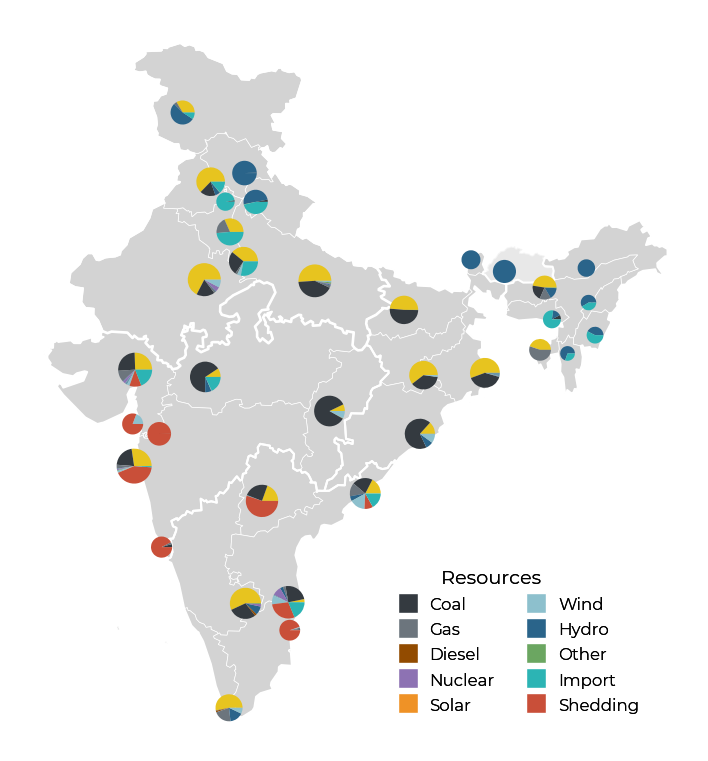

In [15]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def _plot_generation_status(ax, df_gen_, load_zones_, 
                            abr = False, 
                            legend = True):
    
    def __f(total):
        return np.sqrt(np.sqrt(np.sqrt(total/1e3)))/4
    
    df_ = df_gen_.copy()
    
    for load_zone in df_gen_['load_zone'].unique():

        idx_ = load_zones_['load_zone'] == load_zone
        x    = load_zones_.loc[idx_, 'longitude'].to_numpy()[0]
        y    = load_zones_.loc[idx_, 'latitude'].to_numpy()[0]

        df_lz_gen_ = df_gen_.loc[df_gen_['load_zone'] == load_zone].reset_index(drop = True)
        idx_p_     = df_lz_gen_['technology'] == 'Load'
        load       = df_lz_gen_.loc[idx_p_, 'power_mw'].to_numpy()[0]
        df_lz_gen_ = df_lz_gen_.loc[~idx_p_].reset_index(drop = True)

        width = __f(int(load))

        axp_ = inset_axes(ax, width          = width, 
                              height         = width, 
                              bbox_to_anchor = (x, y),
                              loc            = 10, 
                              bbox_transform = ax.transData, 
                              borderpad      = 0)

        wedges, texts = axp_.pie(df_lz_gen_['power_mw']/load,
                                 colors = [tech_labels_.loc[tech_labels_['group'] == tech, 'group_color'].to_numpy()[0] 
                                           for tech in df_lz_gen_['technology']])
    
        for w in wedges:
            w.set_linewidth(.001)
            w.set_edgecolor('k')

        if abr:
            abr = load_zones_.loc[idx_, 'load_zone_abr'].to_numpy()[0]
            if load_zones_.loc[idx_, 'position'].to_numpy()[0] == 0:
                axp_.set_ylabel(f'{abr}', fontsize = 10, labelpad = 8, rotation = 0)

            if load_zones_.loc[idx_, 'position'].to_numpy()[0] == 1:
                if (abr == 'ML'):
                    axp_.set_ylabel(f'{abr}', fontsize = 10, labelpad = 10, rotation = 0, y = .65)
                elif abr == 'JK':
                    axp_.set_ylabel(f'JKLA', fontsize = 10, labelpad = 18, rotation = 0)
                elif abr == 'DH':
                    axp_.set_ylabel(f'DH', fontsize = 10, labelpad = 24, rotation = 0)
                elif abr == 'OR':
                    axp_.set_ylabel(f'OD', fontsize = 10, labelpad = 10, rotation = 0)
                else:
                    axp_.set_ylabel(f'{abr}', fontsize = 10, labelpad = 12, rotation = 0)
                axp_.yaxis.set_label_position('right') 

            if load_zones_.loc[idx_, 'position'].to_numpy()[0] == 2:
                if (abr == 'BH') | (abr == 'HR'):
                    axp_.set_xlabel(f'{abr}', fontsize = 10, labelpad = -6, x = -.1)
                elif (abr == 'AS'):
                    axp_.set_xlabel(f'{abr}', fontsize = 10, labelpad = -7, x = -.03)
                else:
                    axp_.set_xlabel(f'{abr}', fontsize = 10, labelpad = -6, x = -.5)

            if load_zones_.loc[idx_, 'position'].to_numpy()[0] == 3:
                axp_.set_xlabel(f'{abr}', fontsize = 10, labelpad = -1.5)
                axp_.xaxis.set_label_position('top') 

    _nothern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _northeastern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _western.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _southern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _eastern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')

    _bhutan.plot(ax = ax, zorder = 1, color = 'lightgray', lw = 1.5, alpha = .5, edgecolor = 'white')
    _india.plot(ax = ax, zorder = 1, color = 'lightgray', lw = 0.5, edgecolor = 'white')

    resource_handle_ = []
    technologis_ = ['Coal', 'Gas', 'Diesel', 'Nuclear', 'Solar', 'Wind',  'Hydro', 'Other', 'Import','Shedding']
    for tech in technologis_:
        color = tech_labels_.loc[tech_labels_['group'] == tech, 'group_color'].to_numpy()[0]
        resource_handle_.append(Line2D([], [], 
                                       marker="s", 
                                       markerfacecolor = color, 
                                       markersize = 15, 
                                       markeredgecolor = 'w', 
                                       ls="None",
                                       label = tech) ) 
 
    if legend:
        leg4 = ax.legend(handles        = resource_handle_, 
                         bbox_to_anchor = (.935, .265),
                         frameon        = False, 
                         title          = r'Resources           ',
                         title_fontsize = 14,
                         ncol           = 2,
                         fontsize       = 12) 

        
        ax.add_artist(leg4)
    
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

    ax.set_xticks([], [])
    ax.set_yticks([], [])

fig, ax = plt.subplots(1, 1, figsize = (7.5, 7.5), constrained_layout = True)

_plot_generation_status(ax, df_gen_, load_zones_p_, 
                        abr    = False, 
                        legend = True)

plt.savefig(path_to_images + '/generation.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

50.0 34162.14225739856


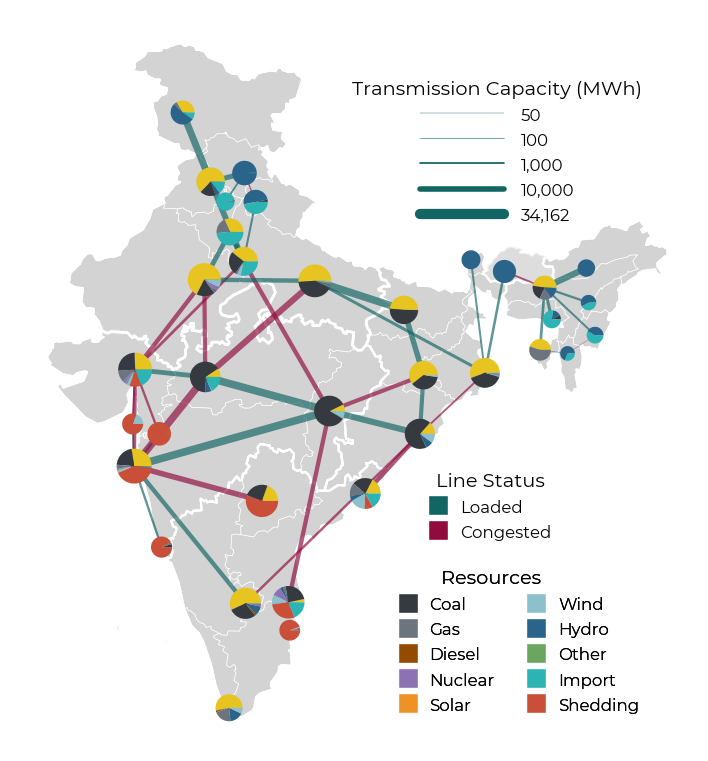

In [19]:
fig, ax = plt.subplots(1, 1, figsize = (7.5, 7.5), constrained_layout = True)

_plot_transmission_status(ax, df_flows_, load_zones_p_, 
                          arrow  = False, 
                          legend = True, 
                          idle   = False)

_plot_generation_status(ax, df_gen_, load_zones_p_, 
                        abr    = False,
                        legend = True)

plt.savefig(path_to_images + '/lines_congention_and_generation.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [80]:
tech_labels_ = pd.read_csv('/home/gterren/india_power/gridpath_india_viz/csvs/technology_labels.csv')
print(tech_labels_)

                  group              technology group_color    color  order  \
0                  Coal  Subcritical_Coal_Large     #343a40  #343a40      1   
1                  Coal  Subcritical_Coal_Small     #343a40  #343a40      1   
2                  Coal      Supercritical_Coal     #343a40  #343a40      1   
3                   Gas                    CCGT     #6c757d  #6c757d      2   
4                   Gas                      CT     #6c757d  #6c757d      2   
5                Diesel                  Diesel     #924B00  #924B00      3   
6               Nuclear                 Nuclear     #8d72b3  #8d72b3      4   
7                 Other                 Biomass     #6ba661  #6a96ac      5   
8                 Other                     WHR     #6ba661  #6ba661      5   
9                 Hydro               Hydro_ROR     #2a648a  #2a648a      6   
10                Hydro           Hydro_Storage     #2a648a     lime      6   
11                Solar            SolarPV_tilt     

['Coal' 'Gas' 'Diesel' 'Nuclear' 'Other' 'Hydro' 'Solar' 'Wind'
 'Pumped Storage' 'Battery' 'Hydrogen' 'Import' 'Shedding'
 'Transmission Losses' 'Export' 'Curtailment']
Shedding
Import
Wind
Solar
Hydro
Other
Nuclear
Diesel
Gas
Coal
Pumped Storage
Battery
Hydrogen
Transmission Losses
Export
Curtailment


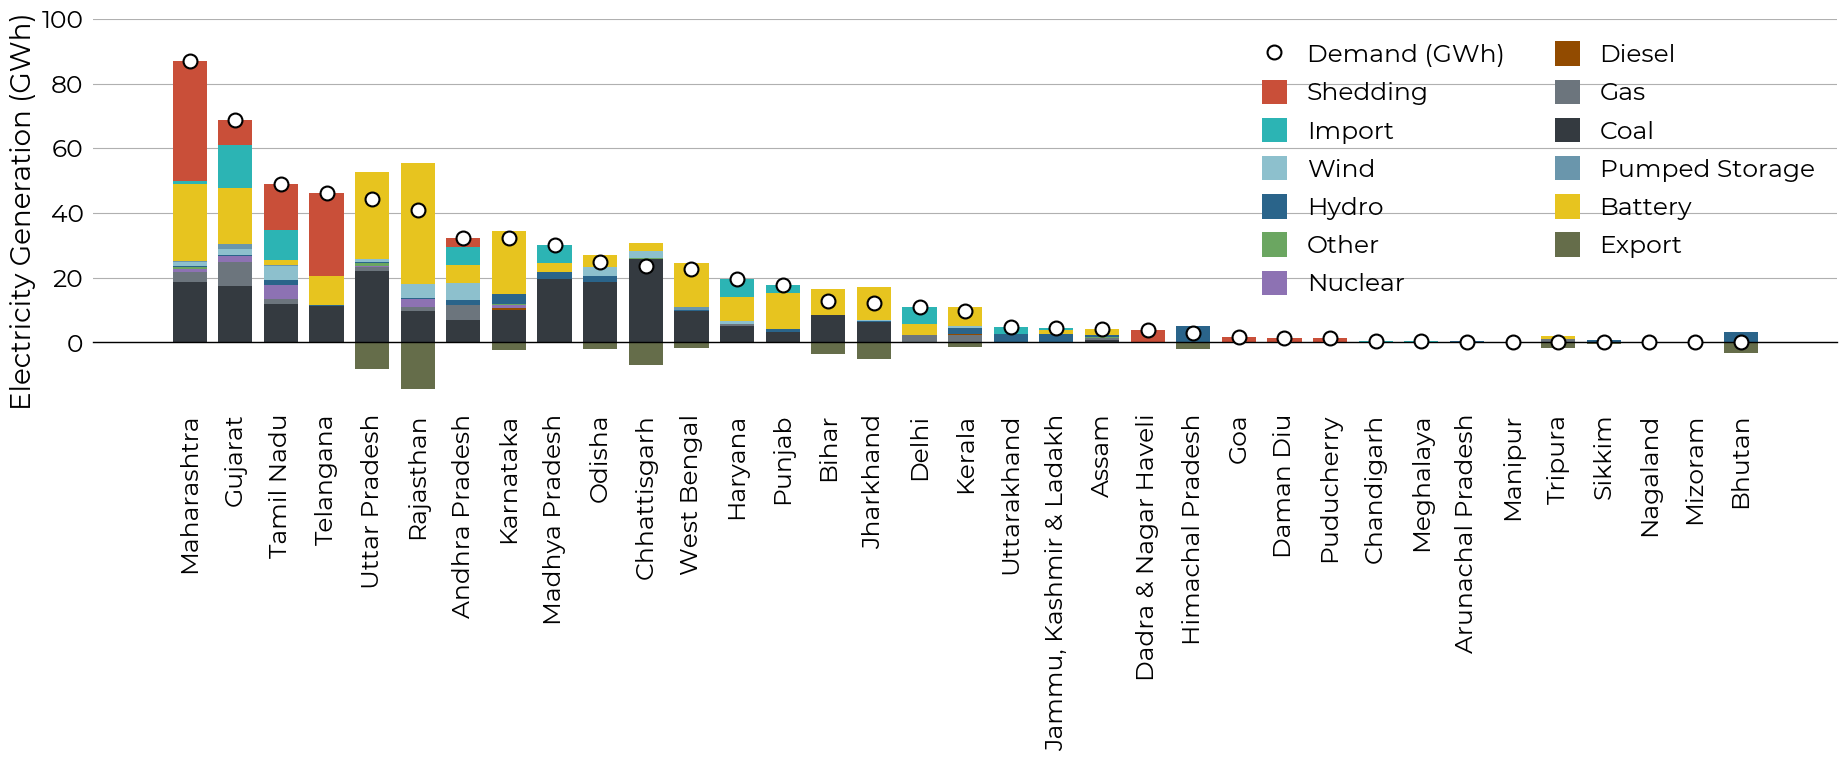

In [ ]:
def _plot_dispatch_by_zone(ax, df_gen_, tech_label_, 
                           units     = 1e3,
                           y_lim_min = -10,
                           y_lim_max = 10,
                           ylabel    = r'Electricity Generation (GWh)',
                           legend    = True,
                           title     = ''):

    def __make_dispatch_legend(ax, df_, techs_):
        
        tech_idx_ = np.sort(np.unique(techs_['order_v2']))
        
        for i_tech in tech_idx_[::-1]:
            
            tech  = tech_label_.loc[tech_label_['order_v2'] == i_tech, 'group'].unique()[0]
            color = tech_label_.loc[tech_label_['order_v2'] == i_tech, 'group_color'].unique()[0]
            idx_  = df_['technology'] == tech

            if idx_.sum() > 0:
                if df_.loc[idx_, 'power_mw'].sum() != 0:
                    ax.bar(0., 0., 0., bottom = 0.,
                                       color  = color,
                                       label  = tech,
                                       zorder = 10)

    techs_, idx_ = np.unique(tech_label_['group'], return_index = True)
    techs_       = techs_[np.argsort(idx_)]
    colors_      = tech_label_.loc[tech_label_.index[idx_], 'group_color'].to_list()
    
    width = 0.75

    ticks_    = []
    labels_   = []
    x_period_ = []
    y_period_ = []
    
    offset_positive = 0.
    offset_negative = 0.    
    y_max           = 0
    y_min           = 0

    df_              = df_gen_.copy()
    LZ_              = df_.loc[df_['technology'] == 'Load', ['load_zone', 'power_mw']].to_numpy()
    load_zones_sort_ = LZ_[np.argsort(LZ_[:, 1])[::-1], 0] 
    x_               = np.linspace(0, len(load_zones_sort_) - 1, len(load_zones_sort_))

    __make_dispatch_legend(ax, df_, tech_label_)

    for load_zone, i_zone in zip(load_zones_sort_, range(len(load_zones_sort_))):
        for tech in techs_:
            idx_ = (df_['load_zone'] == load_zone) & (df_['technology'] == tech)

            if idx_.sum() == 1:
                power = float(df_.loc[idx_, 'power_mw'].to_numpy()[0])

                if power != 0:
                    if power > 0:
                        offset = offset_positive
                    else:
                        offset = offset_negative

                    ax.bar(x_[i_zone], power/units, width, 
                           bottom = offset/units,
                           color  = tech_label_.loc[tech_label_['group'] == tech, 'group_color'].unique(),
                           zorder = 2,
                           ec     = 'None',
                           lw     = 0.,
                           aa     = True)

                    if power >= 0:
                        offset_positive += power
                    else:
                        offset_negative += power

        if offset_negative/units < y_min: 
            y_min = offset_negative/units
            
        if offset_positive/units > y_max: 
            y_max = offset_positive/units

        power = df_.loc[(df_['load_zone'] == load_zone) & (df_['technology'] == 'Load'), 'power_mw'].to_numpy()[0]

        if i_zone == 0:
            ax.plot(x_[i_zone], power/units, 
                    marker          = 'o', 
                    ms              = 10,
                    markeredgewidth = 1.5,
                    c               = 'white', 
                    label           = 'Demand (GWh)',
                    zorder          = 11,
                    markeredgecolor = 'k')
        else:
            ax.plot(x_[i_zone], power/units, 
                    marker          = 'o', 
                    ms              = 10,
                    markeredgewidth = 1.5,
                    c               = 'white', 
                    zorder          = 11, 
                    markeredgecolor = 'k')
        
        ticks_.append(x_[i_zone])
        labels_.append(load_zone)
        x_period_.append(x_[i_zone])
        y_period_.append(offset_positive)

        offset_positive = 0.
        offset_negative = 0.

    x_ = x_ + .9/len(load_zones_sort_)        
    
    labels_ = []
    for load_zone in load_zones_sort_:
        label = '{}'.format(load_zone.replace("_", " "))
        label = label.replace("Jammu Kashmir", "Jammu, Kashmir & Ladakh")
        label = label.replace("Dadra Nagar Haveli", "Dadra & Nagar Haveli")
        labels_.append(label)
        
    ax.set_xticks(ticks_, labels_, 
                  fontsize = 20, 
                  rotation = 90, 
                  ha = 'center')
    
    ax.set_ylabel(ylabel, fontsize = 20)

    ax.xaxis.set_tick_params(labelsize = 18, left = False)
    ax.yaxis.set_tick_params(labelsize = 18, left = False)
    
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    if legend:
        ax.legend(loc            = 'upper right',
                  #bbox_to_anchor = (1., .9),
                  ncol           = 2,
                  frameon        = False,
                  prop           = {'size': 18})

    ax.set_ylim(y_lim_min, y_lim_max)
    # ax.set_xlim(-.75, len(zones_) - 0.25)
        
    ax.axhline(0, linewidth = 1., 
                  linestyle = '-', 
                  color     = 'k', 
                  clip_on   = False, 
                  zorder    = 10)
    
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    #ax.grid(axis = 'y', ls = ':', lw = 1.25)
    ax.grid(axis = 'y')

fig = plt.figure(figsize = (22.5, 5))
_ax = plt.subplot(111)

_plot_dispatch_by_zone(_ax, df_gen_, tech_labels_, 
                       y_lim_min = -21,
                       y_lim_max = 100,
                       title     = r'',
                       ylabel    = 'Electricity Generation (GWh)')

plt.savefig(path_to_images + '/state-level_generation.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [17]:
LOLEv_ = USE_.groupby(['month', 
                       'day', 
                       'hour', 
                       'iteration']).agg({'unserved_energy': 'sum',
                                          'n_events': 'sum'}).reset_index(drop = False)
print(LOLEv_)

    month  day  hour  iteration  unserved_energy  n_events
0       2    7     7         17     43206.018979         5
1       2    7    17         17     37757.869151         4
2       2    9     7         11      4907.529182         1
3       2    9     9         11      2981.375866         1
4       2   10     7         17      6143.906847         1
..    ...  ...   ...        ...              ...       ...
86     12    2    18         16      2266.275226         3
87     12   13     7         12      3729.802339         4
88     12   13    17         12     16604.068541         7
89     12   29     9          6       970.584514         1
90     12   29    15          6      1302.571553         2

[91 rows x 6 columns]


In [18]:
# Load and processing system load timepoints
def _processing_transmission_timepoints(scenarios_, iteration, month, day, hour):

    df_flows_ = []
    df_loads_ = []
    df_projects_ = []

    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)
        for dirpath, dirnames, filenames in os.walk(path_to_scenario):

            if dirpath.split('/')[-1] == 'results':

                # Add iteration descriptors to dataframe
                I = dirpath.split('/')[-6].split('_')[-1]

                W = dirpath.split('/')[-5].split('_')[-1]
                H = dirpath.split('/')[-4].split('_')[-1]
                A = dirpath.split('/')[-3].split('_')[-1]

                if iteration == int(I):

                    df_flow_ = pd.read_csv(os.path.join(dirpath, 'transmission_timepoint.csv'), low_memory = False)
                    df_flow_['transmission_line'] = df_flow_['transmission_line'].str.replace('_new','')
                    
                    df_flow_['timepoint'] = df_flow_['timepoint'].astype(str)
                    df_flow_['month']     = df_flow_['timepoint'].str[4:6].astype(int)
                    df_flow_['day']       = df_flow_['timepoint'].str[6:8].astype(int)
                    df_flow_['hour']      = df_flow_['timepoint'].str[8:10].astype(int)
   
                    df_flows_.append(df_flow_)

                    df_tx_ = pd.read_csv(os.path.join(dirpath, 'transmission_period.csv'), low_memory = False)
                    df_tx_['transmission_line'] = df_tx_['transmission_line'].str.replace('_new','')

    df_flows_ = pd.concat(df_flows_).reset_index(drop = True)

    idx_ = df_flows_['month'] == month
    idx_ = idx_ & (df_flows_['day'] == day)          
    idx_ = idx_ & (df_flows_['hour'] == hour)     

    df_flows_ = df_flows_.loc[idx_].reset_index(drop = True)

    df_flows_ = df_flows_.groupby(['transmission_line', 
                                   'load_zone_from', 
                                   'load_zone_to']).agg({'transmission_flow_mw': 'sum', 
                                                         'transmission_losses_lz_from': 'sum', 
                                                         'transmission_losses_lz_to': 'sum'}).reset_index(drop = False)
    
    df_tx_ = df_tx_.groupby(['transmission_line', 
                             'load_zone_from', 
                             'load_zone_to']).agg({'max_mw': 'sum'}).reset_index(drop = False)

    df_flows_ = pd.merge(df_flows_, df_tx_, on = ['transmission_line', 
                                                  'load_zone_from', 
                                                  'load_zone_to'], how = 'inner')

    return df_flows_

dfs_lines_ = []
for i in range(LOLEv_.shape[0]):
    iteration = LOLEv_.loc[i, 'iteration']
    month     = LOLEv_.loc[i, 'month']
    day       = LOLEv_.loc[i, 'day']
    hour      = LOLEv_.loc[i, 'hour']
    print(i, iteration, month, day, hour)

    df_flows_ = _processing_transmission_timepoints(scenarios_, iteration, month, day, hour)
    
    df_flows_['capacity_factor'] = 100.*np.abs(df_flows_['transmission_flow_mw'])/df_flows_['max_mw']

    dfs_lines_.append(df_flows_.loc[df_flows_['capacity_factor'] >= 99., ['transmission_line', 
                                                                          'load_zone_from', 
                                                                          'load_zone_to', 
                                                                          'max_mw']])


dfs_lines_ = pd.concat(dfs_lines_, axis = 0).reset_index(drop = True)
print(dfs_lines_.shape)

0 17 2 7 7
1 17 2 7 17
2 11 2 9 7


KeyboardInterrupt: 

In [ ]:
dfs_lines_['n_events'] = 1

dfs_agg_lines_ = dfs_lines_.groupby(['transmission_line', 
                                     'load_zone_from', 
                                     'load_zone_to',
                                     'max_mw']).agg({'n_events': 'sum'}).reset_index(drop = False).copy()

#print(dfs_agg_lines_.sort_values(by = 'n_events', ascending = False))

df_lines_ = df_flows_[['transmission_line', 
                       'load_zone_from', 
                       'load_zone_to', 
                       'max_mw']].copy()
# df_lines_['n_events'] = 0

dfs_agg_lines_ = pd.merge(df_lines_, dfs_agg_lines_, on = ['transmission_line', 
                                                           'load_zone_from', 
                                                           'load_zone_to', 
                                                           'max_mw'], how = 'left').fillna(0.)

50.0 34162.14225739856


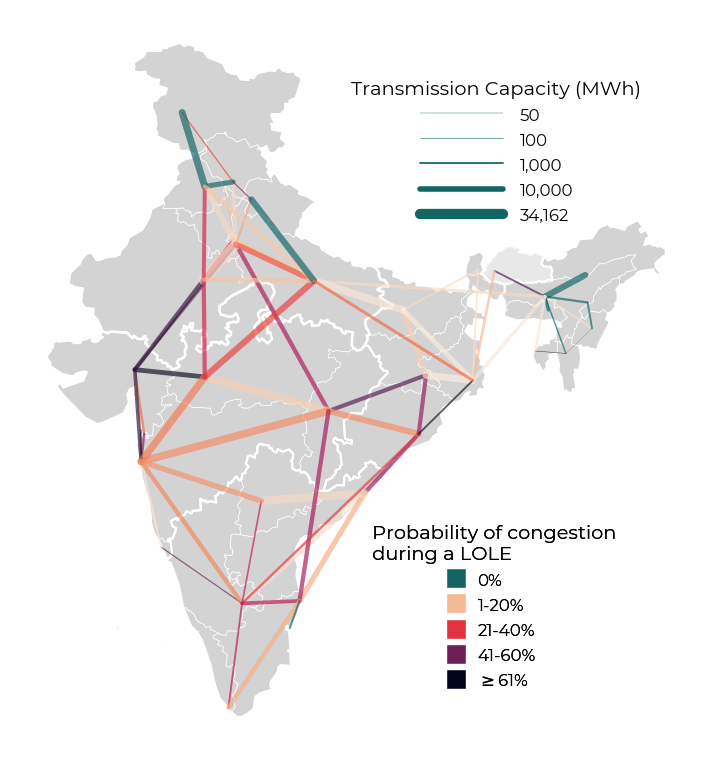

In [ ]:
def _plot_transmission_failure(ax, df_lines_, load_zones_,  
                               noprobability = True, 
                               legend = True):

    def __f(x):
        return np.sqrt(np.absolute(x))/25
    
    df_ = df_lines_.copy()
    tx_min = df_['max_mw'].min()
    tx_max = df_['max_mw'].max()
    print(tx_min, tx_max)

    units = 1
    _norm = colors.Normalize(vmin = 1, vmax = df_['n_events'].max())
    #_cmap = LinearSegmentedColormap.from_list("my_two", ['#2cb7b5','#136564'])
    _cmap = plt.get_cmap("rocket_r")

    for i in range(df_.shape[0]):
        load_zone_to_   = load_zones_.loc[load_zones_['load_zone'] == df_.loc[i, 'load_zone_to']]
        load_zone_from_ = load_zones_.loc[load_zones_['load_zone'] == df_.loc[i, 'load_zone_from']]

        lon_from = load_zone_from_['longitude'].to_numpy()[0]
        lon_to   = load_zone_to_['longitude'].to_numpy()[0]
        
        B = df_.loc[i, 'max_mw']
        E = df_.loc[i, 'n_events']
        z = __f(B/units)

        x_ = np.concatenate([load_zone_from_['latitude'].to_numpy(), load_zone_to_['latitude'].to_numpy()], axis = 0)
        y_ = np.concatenate([load_zone_from_['longitude'].to_numpy(), load_zone_to_['longitude'].to_numpy()], axis = 0)

        if E == 0:
            if noprobability:
                line = ax.plot(y_, x_, 
                        lw             = z,
                        zorder         = 10, 
                        color          = '#136564',
                        solid_capstyle = 'round', 
                        alpha          = .675)
        else:
            line = ax.plot(y_, x_, 
                        lw             = z,
                        zorder         = 10, 
                        color          = _cmap(_norm(E)),
                        solid_capstyle = 'round', 
                        alpha          = .675)
            
    _india.plot(ax = ax, zorder = 1, color = 'lightgray', lw = 0.5, edgecolor = 'white')
    _bhutan.plot(ax = ax, zorder = 1, color = 'lightgray', lw = 1.5, alpha = .5, edgecolor = 'white')

    _nothern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _northeastern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _western.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _southern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
    _eastern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')

    if legend:
        line1 = Line2D([], [], color = '#136564', lw = __f(tx_min/units), solid_capstyle ='round')
        line2 = Line2D([], [], color = '#136564', lw = __f(100/units), solid_capstyle ='round')
        line3 = Line2D([], [], color = '#136564', lw = __f(1000/units), solid_capstyle ='round')
        line4 = Line2D([], [], color = '#136564', lw = __f(10000/units), solid_capstyle ='round')
        line5 = Line2D([], [], color = '#136564', lw = __f(tx_max/units), solid_capstyle ='round')
    
        leg1 = ax.legend((line1, line2, line3, line4, line5), 
                         (f'{int(tx_min):,}', f'{int(100):,}', f'{int(1000):,}', f'{int(10000):,}', f'{int(tx_max):,}'), 
                         title_fontsize = 14,
                         title          = 'Transmission Capacity (MWh)',
                         handlelength   = 5.,
                         handletextpad  = 1.,
                         labelspacing   = .5,
                         frameon        = False, 
                         bbox_to_anchor = (0.475, 0.925), 
                         prop           = {'size': 12})
        
        ax.add_artist(leg1) 

    risk_handle = []
        
    if noprobability:
        risk_handle.append(Line2D([0], [0],
                           marker="s",              # square marker
                           color="none",            # no line
                           markerfacecolor='#136564',
                           markersize=15,
                           markeredgecolor = 'w',
                           linestyle="None",
                           label=r"0%") )
    
    risk_handle.append(Line2D([0], [0],
                        marker="s",              # square marker
                        color="none",            # no line
                        markerfacecolor=_cmap(_norm(10)),
                        markersize=15,
                        markeredgecolor = 'w',
                        linestyle="None",
                        label=r"1-20%") )

    risk_handle.append(Line2D([0], [0],
                        marker="s",              # square marker
                        color="none",            # no line
                        markerfacecolor=_cmap(_norm(30)),
                        markersize=15,
                        markeredgecolor = 'w',
                        linestyle="None",
                        label=r"21-40%") )

    risk_handle.append(Line2D([0], [0],
                        marker="s",              # square marker
                        color="none",            # no line
                        markerfacecolor=_cmap(_norm(50)),
                        markersize=15,
                        markeredgecolor = 'w',
                        linestyle="None",
                        label=r"41-60%") )
    
    risk_handle.append(Line2D([0], [0],
                        marker="s",              # square marker
                        color="none",            # no line
                        markerfacecolor=_cmap(_norm(70)),
                        markersize=15,
                        markeredgecolor = 'w',
                        linestyle="None",
                        label=r"$\geq$61%") )

    leg2 = ax.legend(handles=risk_handle, 
                        loc=(0.51, 0.075), 
                        frameon = False, 
                        title = ' Probability of congestion\n during a LOLE',
                        title_fontsize = 14,
                        fontsize = 12) 

    ax.add_artist(leg2) 

    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

    ax.set_xticks([], [])
    ax.set_yticks([], [])

fig, ax = plt.subplots(1, 1, figsize = (7.5, 7.5), constrained_layout = True)

_plot_transmission_failure(ax, dfs_agg_lines_, load_zones_, 
                           noprobability = True, 
                           legend = True)

plt.savefig(path_to_images + '/lines_congestion_probability.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()